In [206]:
import pandas as pd 
import numpy as np

In [207]:
df=pd.read_csv("C:\\Users\\jojic\\OneDrive\\Desktop\\mljourney\\gui-building\\drug_type\\drug_prediction.csv")

In [208]:
df.isnull().sum()

Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

In [209]:
df[df.duplicated].shape

(14, 6)

In [210]:
df=df.drop_duplicates()
df[df.duplicated].shape  

(0, 6)

In [211]:
df["Sex"]=df["Sex"].map({"M":0,"F":1})
df["BP"]=df["BP"].map({'HIGH':0,'NORMAL':1,'LOW':2})
df["Cholesterol"]=df["Cholesterol"].map({'HIGH':0, 'NORMAL':1}) 

<Axes: >

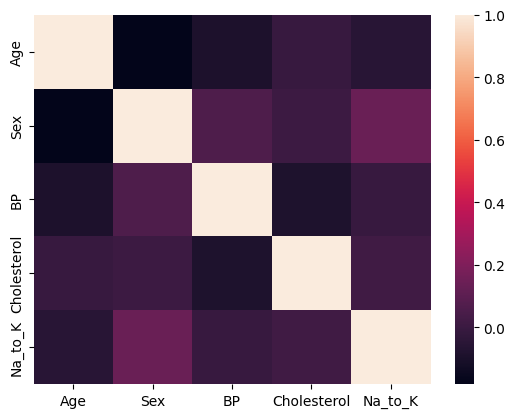

In [212]:
import seaborn as sns
col=["Age","Sex","BP","Cholesterol","Na_to_K"]
sns.heatmap(df[col].corr())

In [213]:
x=df.iloc[:,:-1] 
y=df.iloc[:,-1]
x.head()

,Age,Sex,BP,Cholesterol,Na_to_K
0,26,1,0,1,12.48
1,40,0,2,0,11.31
2,35,1,0,1,12.03
3,24,0,2,0,6.89
4,69,0,2,0,6.91


In [214]:
df["Drug"].value_counts()

Drug
drugX    400
DrugY    399
drugA    397
drugB    395
drugC    395
Name: count, dtype: int64

In [224]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y=le.fit_transform(y)
y

array([1, 3, 1, ..., 4, 1, 0], shape=(1986,))

In [216]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)

In [217]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test) 

In [218]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,f1_score
knn = KNeighborsClassifier()
knn.fit(x_train,y_train)
y_pred = knn.predict(x_test)
print("accuracy_score",accuracy_score(y_test,y_pred)*100) 
print("f1_score",f1_score(y_test,y_pred,average="macro")*100) 

accuracy_score 91.20603015075378
f1_score 91.32762721999556


In [219]:
params = {
    "n_neighbors":[3,5,7,9],
    "weights":["uniform","distance"],
    "algorithm":["auto","ball_tree","kd_tree","brute"]
}

In [220]:
from sklearn.model_selection import GridSearchCV
gs = GridSearchCV(knn,params,cv=10)
gs.fit(x_train,y_train)
gs.best_params_

{'algorithm': 'auto', 'n_neighbors': 3, 'weights': 'distance'}

In [221]:
knn = KNeighborsClassifier(algorithm="auto",n_neighbors=5,weights="distance")
knn.fit(x_train,y_train)
y_pred = knn.predict(x_test)
print("accuracy_score",accuracy_score(y_test,y_pred)*100) 
print("f1_score",f1_score(y_test,y_pred,average="macro")*100)

accuracy_score 93.46733668341709
f1_score 93.55623424855223


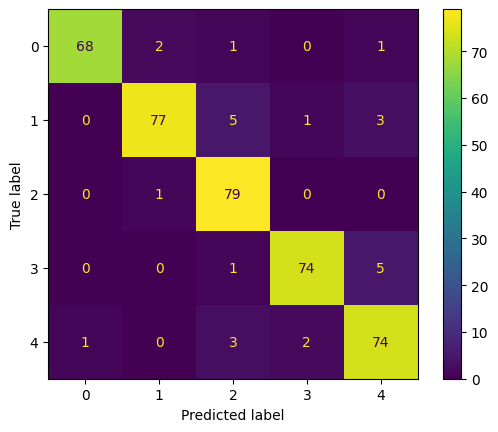

In [222]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test,y_pred) 

In [223]:
import joblib
joblib.dump(knn,"dt_model.pkl")
joblib.dump(scaler,"scaler.pkl") 

['scaler.pkl']